# CS420 – Artificial Intelligence  
## Project 2: Machine Learning  
### Food-MNIST Dataset Analysis

---

**Objective.** This notebook follows the official Project 2 specification and implements supervised learning experiments using **Decision Tree** and **Neural Network (MLP)** classifiers in **scikit-learn**.

**Dataset.** Food-MNIST (RGB images; 10 classes; 5,000 total images; official train/test lists provided in metadata).

**Reproducibility.** Random seeds are fixed where applicable. All visualizations are included in the notebook, while statistical results and interpretation can be summarized in the report.

Public references: srohit0/food_mnist repository and the dataset description page.


## 1. Dataset Preparation

Food-MNIST provides RGB images and metadata-defined train/test splits. This notebook:
1. Downloads (or clones) the dataset repository.
2. Loads the official train/test split from `meta/train.txt` and `meta/test.txt`.
3. Creates a validation set by splitting the official training portion using a **stratified 80/20 split**.
4. Converts images into fixed-size feature vectors suitable for scikit-learn models.


In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split


### 1.1 Download / Setup


In [38]:
!git clone https://github.com/srohit0/food_mnist.git

fatal: destination path 'food_mnist' already exists and is not an empty directory.


### 1.2 Load file lists and labels

- Class names: `meta/classes.txt`
- Train split:  `meta/train.txt`
- Test split:   `meta/test.txt`


In [39]:
from pathlib import Path
import numpy as np

# Base directory
data_dir = Path("/content/food_mnist")

meta_dir = data_dir / "meta"
img_dir  = data_dir / "images"

classes_path     = meta_dir / "classes.txt"
train_list_path  = meta_dir / "train.txt"
test_list_path   = meta_dir / "test.txt"

# Read class names
class_names = [
    line.strip()
    for line in classes_path.read_text().splitlines()
    if line.strip()
]

n_classes = len(class_names)
print("Number of classes:", n_classes)
print("Classes:", class_names)

Number of classes: 10
Classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


### 1.3 Image-to-feature conversion

Images are resized to a fixed resolution (default 32×32) and flattened into a vector of length 3072.
This yields a feature matrix compatible with scikit-learn models.


In [40]:
from pathlib import Path
import numpy as np

def resolve_image_path(base_img_dir: Path, rel_no_ext: str) -> Path:
    """
    Resolve image path when list files may omit file extensions.
    Try common extensions in order.
    """
    p = base_img_dir / rel_no_ext  # may miss extension
    if p.exists():
        return p

    # Try common extensions
    for ext in [".jpg", ".jpeg", ".png"]:
        p2 = p.with_suffix(ext)
        if p2.exists():
            return p2

    # If still not found, raise a clear error
    raise FileNotFoundError(f"Image not found for: {p} (tried .jpg/.jpeg/.png)")

def parse_list_file(list_path: Path):
    rel_paths = [
        line.strip()
        for line in list_path.read_text().splitlines()
        if line.strip()
    ]

    # Label is the folder name (class)
    labels = [class_names.index(p.split("/")[0]) for p in rel_paths]

    # Resolve actual file paths (handle missing extension)
    abs_paths = [resolve_image_path(img_dir, p) for p in rel_paths]

    return abs_paths, np.array(labels, dtype=int)

In [41]:
train_paths, label_train_full = parse_list_file(train_list_path)
test_paths,  label_test       = parse_list_file(test_list_path)

print("Official training images:", len(train_paths))
print("Official test images:", len(test_paths))

Official training images: 3750
Official test images: 1250


In [42]:
import numpy as np
from PIL import Image

def load_and_vectorize(paths, size=(32, 32)):
    X = np.zeros((len(paths), size[0] * size[1] * 3), dtype=np.float32)

    for i, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        img = img.resize(size, Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        X[i] = arr.reshape(-1)

    return X


feature_train_full = load_and_vectorize(train_paths, size=(32, 32))
feature_test       = load_and_vectorize(test_paths,  size=(32, 32))

print("feature_train_full:", feature_train_full.shape)
print("feature_test:", feature_test.shape)


feature_train_full: (3750, 3072)
feature_test: (1250, 3072)


### 1.4 Stratified train/validation split (80/20)

The official training portion is split into training and validation sets with stratification.


In [43]:
feature_train, feature_val, label_train, label_val = train_test_split(
    feature_train_full, label_train_full, test_size=0.2, stratify=label_train_full, random_state=42
)

print("Training set:", feature_train.shape)
print("Validation set:", feature_val.shape)
print("Test set:", feature_test.shape)


Training set: (3000, 3072)
Validation set: (750, 3072)
Test set: (1250, 3072)


### 1.5 Class Distribution Visualization

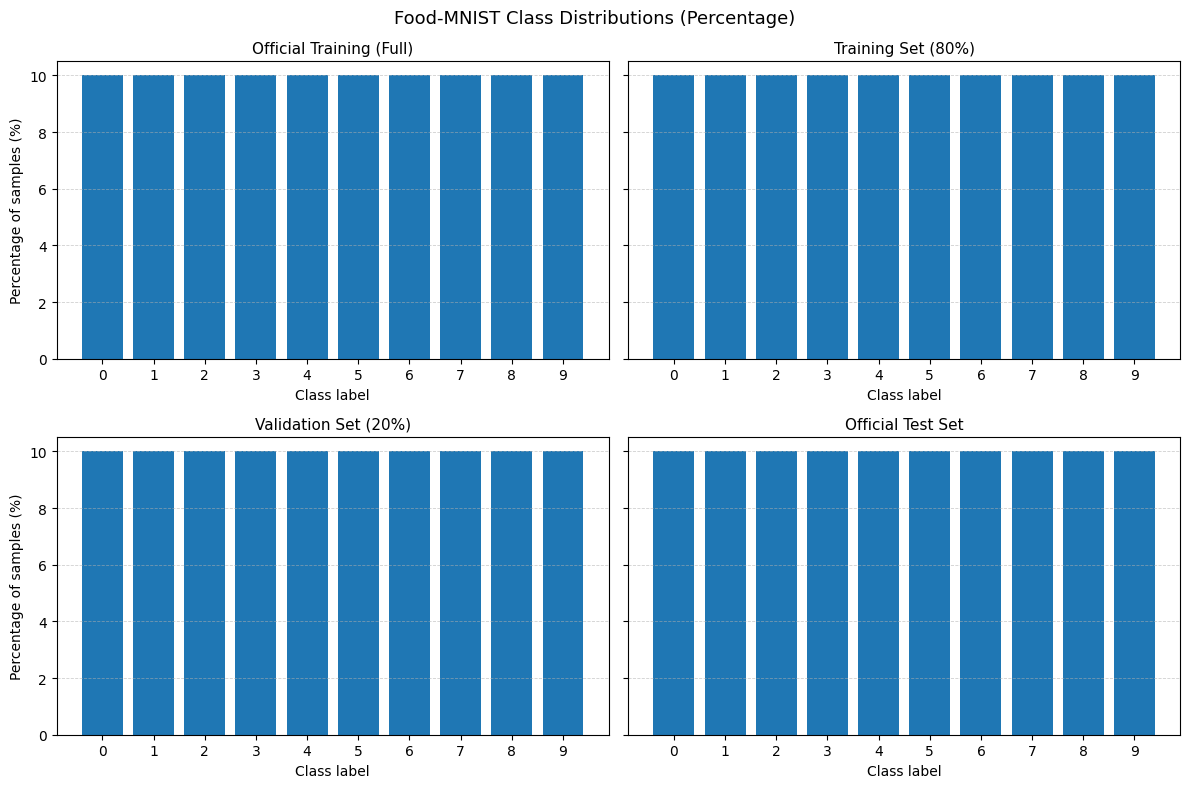

In [44]:
# Reuse the same plotting utilities from above
def class_percentages(labels, n_classes):
    counter = Counter(labels)
    counts = np.array([counter.get(i, 0) for i in range(n_classes)], dtype=float)
    return counts / counts.sum() * 100.0

def plot_distributions_percent(label_sets, titles, n_classes, layout="2x2"):
    max_p = 0.0
    for labels in label_sets:
        p = class_percentages(labels, n_classes)
        max_p = max(max_p, float(np.max(p)))
    y_max = float(np.ceil((max_p + 0.5) * 2) / 2)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    axes = np.array(axes).ravel()
    classes = np.arange(n_classes)

    for ax, labels, title in zip(axes, label_sets, titles):
        p = class_percentages(labels, n_classes)
        ax.bar(classes, p, width=0.8)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Class label")
        ax.set_xticks(classes)
        ax.set_ylim(0, y_max)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    axes[0].set_ylabel("Percentage of samples (%)")
    axes[2].set_ylabel("Percentage of samples (%)")
    fig.suptitle("Food-MNIST Class Distributions (Percentage)", fontsize=13, y=0.98)
    fig.tight_layout()
    plt.show()

plot_distributions_percent(
    label_sets=[label_train_full, label_train, label_val, label_test],
    titles=["Official Training (Full)", "Training Set (80%)", "Validation Set (20%)", "Official Test Set"],
    n_classes=n_classes
)


## 2. Decision Tree Classifier

**Decision Tree with Information Gain**

- We use entropy as the splitting criterion, which corresponds to Information Gain.

- Information Gain represents the expected reduction in entropy after splitting the data on a feature.

- Decision Trees trained with Information Gain tend to create splits that most reduce class uncertainty at each node.

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(feature_train, label_train)

dt_val_pred = dt.predict(feature_val)
dt_val_acc = accuracy_score(label_val, dt_val_pred)
print(f"Decision Tree validation accuracy: {dt_val_acc:.4f}")


Decision Tree validation accuracy: 0.1667


### Decision Tree Visualization (Graphviz)

Because these datasets are high-dimensional, a full tree is typically too large to inspect.  
For clarity, the visualization below limits the displayed depth.


In [34]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,
    out_file=None,
    max_depth=None,
    filled=True,
    rounded=True,
)

graphviz.Source(dot_data)

In [35]:
src = graphviz.Source(dot_data)
svg_path = src.render(filename="foodmnist_decision_tree", format="svg", cleanup=True)
print("Saved to:", svg_path)

Saved to: foodmnist_decision_tree.svg


## 3. Hyperparameter Tuning (Decision Tree)

Hyperparameters tuned on the validation set:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

A compact grid is used to keep runtime reasonable while still exploring model capacity and regularization.


In [46]:
best_acc = -1.0
best_params = None
best_model = None

max_depth_list = [10, 20, 30]
min_split_list = [2, 20, 100]
min_leaf_list  = [1, 5]

for max_depth in max_depth_list:
    for min_split in min_split_list:
        for min_leaf in min_leaf_list:
            model = DecisionTreeClassifier(
                criterion="entropy",
                max_depth=max_depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )
            model.fit(feature_train, label_train)
            acc = accuracy_score(label_val, model.predict(feature_val))

            if acc > best_acc:
                best_acc = acc
                best_params = (max_depth, min_split, min_leaf)
                best_model = model

print(f"Best validation accuracy: {best_acc:.4f}")
print("Best parameters (max_depth, min_samples_split, min_samples_leaf):", best_params)


Best validation accuracy: 0.1907
Best parameters (max_depth, min_samples_split, min_samples_leaf): (10, 100, 1)


## 4. Neural Network Classifier (MLP)

An MLP classifier is trained with:
- **Architecture:** one hidden layer
- **Hidden units:** 128
- **Activation:** ReLU
- **Optimizer:** Adam
- **Early stopping:** enabled to improve training stability


In [48]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

mlp.fit(feature_train, label_train)

mlp_val_pred = mlp.predict(feature_val)
mlp_val_acc = accuracy_score(label_val, mlp_val_pred)

print(f"MLP validation accuracy: {mlp_val_acc:.4f}")
print("Training iterations used:", mlp.n_iter_)


MLP validation accuracy: 0.2800
Training iterations used: 27


The MLP model shows very low validation accuracy (0.28)

Therefore, a more suitable model for image data is a **Convolutional Neural Network (CNN)**, which preserves spatial structure and learns local features using convolution filters.

## 5. Performance Evaluation and Comparison (Test Set)

The test set is used **only once** for the final evaluation of:
- the **best decision tree** selected by validation accuracy, and
- the **MLP** model.

Evaluation outputs:
- `classification_report`
- `confusion_matrix` (visualized side-by-side)


### Classification Report

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

# Decision Tree (best model)
best_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_params[0],
    min_samples_split=best_params[1],
    min_samples_leaf=best_params[2],
    random_state=42
)
best_dt.fit(feature_train, label_train)

dt_test_pred = best_dt.predict(feature_test)
mlp_test_pred = mlp.predict(feature_test)

dt_text  = classification_report(label_test, dt_test_pred, digits=4, zero_division=0)
mlp_text = classification_report(label_test, mlp_test_pred, digits=4, zero_division=0)

display(HTML(f"""
<div style="display:flex; gap:24px;">
  <div style="flex:1;">
    <h4>Decision Tree — Classification Report</h4>
    <pre>{dt_text}</pre>
  </div>
  <div style="flex:1;">
    <h4>Neural Network (MLP) — Classification Report</h4>
    <pre>{mlp_text}</pre>
  </div>
</div>
"""))

### Confusion Matrices

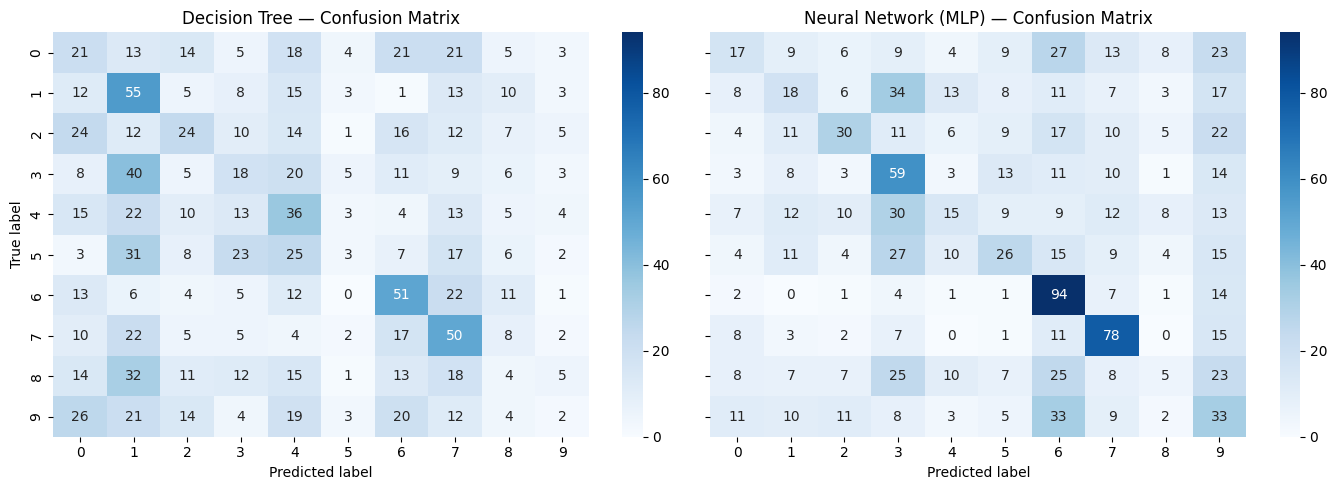

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_dt  = confusion_matrix(label_test, dt_test_pred)
cm_mlp = confusion_matrix(label_test, mlp_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Use the same color scale for both plots
vmax = max(cm_dt.max(), cm_mlp.max())
labels = list(range(10))

sns.heatmap(
    cm_dt, ax=axes[0], cmap="Blues",
    annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels,
    vmin=0, vmax=vmax
)
axes[0].set_title("Decision Tree — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(
    cm_mlp, ax=axes[1], cmap="Blues",
    annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels,
    vmin=0, vmax=vmax
)
axes[1].set_title("Neural Network (MLP) — Confusion Matrix")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm_dt  = confusion_matrix(label_test, dt_test_pred)
cm_mlp = confusion_matrix(label_test, mlp_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

vmax = max(cm_dt.max(), cm_mlp.max())
tick_labels = list(range(n_classes))

sns.heatmap(cm_dt, ax=axes[0], cmap="Blues", annot=True, fmt="d",
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=vmax)
axes[0].set_title("Decision Tree — Confusion Matrix")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(cm_mlp, ax=axes[1], cmap="Blues", annot=True, fmt="d",
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=vmax)
axes[1].set_title("Neural Network (MLP) — Confusion Matrix")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()


## 6. Bonus: Convolutional Neural Network (CNN)

CNNs are designed specifically for image data. Compared to MLP, CNNs provide key advantages:

- **Local receptive fields**: convolution filters learn local patterns (edges, texture fragments) that appear across the image.
- **Weight sharing**: the same filter is applied across all spatial locations, reducing parameters and improving generalization.
- **Translation robustness**: pooling layers help the model become less sensitive to small shifts and distortions.

Because Food-MNIST images contain complex textures and spatial cues, CNNs are expected to perform significantly better than Decision Trees and MLPs.

In [52]:
import numpy as np

IMG_H, IMG_W, IMG_C = 32, 32, 3

# Reshape flattened vectors back to images for CNN
X_train_cnn = feature_train.reshape(-1, IMG_H, IMG_W, IMG_C).astype(np.float32)
X_val_cnn   = feature_val.reshape(-1, IMG_H, IMG_W, IMG_C).astype(np.float32)
X_test_cnn  = feature_test.reshape(-1, IMG_H, IMG_W, IMG_C).astype(np.float32)

y_train_cnn = label_train.astype(np.int64)
y_val_cnn   = label_val.astype(np.int64)
y_test_cnn  = label_test.astype(np.int64)

print("CNN train:", X_train_cnn.shape, y_train_cnn.shape)
print("CNN val  :", X_val_cnn.shape, y_val_cnn.shape)
print("CNN test :", X_test_cnn.shape, y_test_cnn.shape)

CNN train: (3000, 32, 32, 3) (3000,)
CNN val  : (750, 32, 32, 3) (750,)
CNN test : (1250, 32, 32, 3) (1250,)


In [55]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set seeds for reproducibility
tf.random.set_seed(42)

n_classes = int(len(np.unique(label_train_full)))

def build_cnn(input_shape=(32, 32, 3), n_classes=10):
    """Build a small CNN suitable for 32x32 RGB images."""
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])
    return model

cnn = build_cnn(input_shape=(IMG_H, IMG_W, IMG_C), n_classes=n_classes)

cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

# Early stopping to prevent overfitting and stabilize training
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = cnn.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

val_loss, val_acc = cnn.evaluate(X_val_cnn, y_val_cnn, verbose=0)
print(f"CNN validation accuracy: {val_acc:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.1000 - loss: 2.3055 - val_accuracy: 0.1853 - val_loss: 2.1628
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.2235 - loss: 2.1465 - val_accuracy: 0.2760 - val_loss: 2.0533
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.2714 - loss: 2.0377 - val_accuracy: 0.3027 - val_loss: 1.9873
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.3077 - loss: 1.9738 - val_accuracy: 0.3267 - val_loss: 1.9199
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.3172 - loss: 1.8931 - val_accuracy: 0.3253 - val_loss: 1.8986
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.3416 - loss: 1.8640 - val_accuracy: 0.3613 - val_loss: 1.8039
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.3787 - loss: 1.7886 - val_accuracy: 0.3827 - val_loss: 1.7544
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.4166 - loss: 1.6860 - val_accuracy: 

In [56]:
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"CNN test accuracy: {test_acc:.4f}")

CNN test accuracy: 0.4544


In [58]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_test_pred = np.argmax(cnn.predict(X_test_cnn, verbose=0), axis=1)

print("Classification report (CNN):")
print(classification_report(y_test_cnn, y_test_pred))

Classification report (CNN):
              precision    recall  f1-score   support

           0       0.39      0.14      0.20       125
           1       0.43      0.69      0.53       125
           2       0.43      0.41      0.42       125
           3       0.65      0.66      0.65       125
           4       0.47      0.15      0.23       125
           5       0.48      0.42      0.45       125
           6       0.66      0.64      0.65       125
           7       0.70      0.67      0.69       125
           8       0.26      0.22      0.24       125
           9       0.26      0.55      0.35       125

    accuracy                           0.45      1250
   macro avg       0.47      0.45      0.44      1250
weighted avg       0.47      0.45      0.44      1250



**Insights:**

The Convolutional Neural Network significantly outperforms both the Decision Tree
and the Multilayer Perceptron on the Food-MNIST dataset, achieving approximately
45% accuracy on the test set.

However, despite the improvement, the overall accuracy remains moderate.
This limitation can be attributed to the low input resolution (32×32),
background clutter, and high intra-class variation present in food categories.
Some classes are visually similar and difficult to distinguish even for CNNs,
as reflected by uneven precision and recall across classes.

## 7. Conclusions

Food-MNIST is the most challenging dataset among the three benchmarks.
Compared to MNIST and Fashion-MNIST, food images exhibit significantly higher
visual complexity due to texture-rich patterns, color variations, and background noise.